### Applying K Means Clusteting algorithm to cluster satellites into 'shells'
- Since our dataset is completely ready for ML models, we will now group similar satellites together
using k means clustering unsupervised model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [2]:
df = pd.read_csv('../data/04_scaled/satellites_scaled.csv')

In [3]:
df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
0,-2.028257,0.712370,1.364445,-0.995301,-0.036004,1.179214,-0.671252,0.157480,-0.029430,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.408049,0.491618,1.365160,-0.958414,-0.932404,1.642944,5.245827,-0.035489,-0.033018,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-2.720370,2.156456,1.353187,0.367233,-0.923497,1.495113,6.030737,-0.024856,-0.032971,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-2.677392,2.053050,1.349347,-0.460794,1.381571,-1.088367,6.050403,0.002381,-0.032700,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.448113,-0.009803,0.382534,-0.184836,1.362099,-1.349797,-0.724976,0.527563,0.037320,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### K means clustering is based on the distance of the data points from the cluster center. This means that it is a distance based model.

So K means can biase redundant features.
For this reason, we have to select features carefully.

##### Non redundant features to use: 

1. MEAN_MOTION — Defines the orbital shell (altitude).

2. INCLINATION — Separates orbital families (polar, equatorial, ISS-like).

3. ECCENTRICITY — Captures orbit shape.

4. BSTAR — Atmospheric drag indicator; useful for stability differences.

5. AGE_SINCE_LAUNCH — Operational age; helps differentiate older, decaying objects.

6. SAT_TYPE (encoded) — Distinguishes primary vs secondary payload behavior

7. MEAN_MOTION_DOT - Orbital decay rate

8. RA_OF_ASC_NODE (RAAN)- Orbital orientation 


In [4]:
clustering_features = ['MEAN_MOTION', 'INCLINATION', 'ECCENTRICITY', 'BSTAR', 'AGE_SINCE_LAUNCH', 'MEAN_MOTION_DOT', 'RA_OF_ASC_NODE']

# Include sat type columns
sat_type_cols = [col for col in df.columns if 'SAT_TYPE' in col]

clustering_features.extend(sat_type_cols)

X = df[clustering_features].copy()


In [5]:
X.corr(numeric_only=True)

,MEAN_MOTION,INCLINATION,ECCENTRICITY,BSTAR,AGE_SINCE_LAUNCH,MEAN_MOTION_DOT,RA_OF_ASC_NODE,SAT_TYPE_A,SAT_TYPE_B,SAT_TYPE_C,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
MEAN_MOTION,1.000000,-0.368557,-0.128014,-0.008528,-0.298520,0.026269,-0.055647,-0.082529,-0.044979,-0.037842,...,0.017176,0.015939,0.020997,0.022087,0.023469,0.026410,0.025283,0.022115,0.018444,0.010565
INCLINATION,-0.368557,1.000000,0.091231,0.047983,0.226726,0.035156,-0.148730,0.132579,0.044743,0.028399,...,-0.022656,-0.023187,-0.028882,-0.029534,-0.038428,-0.038321,-0.035518,-0.029897,-0.023859,0.003422
ECCENTRICITY,-0.128014,0.091231,1.000000,0.005417,0.184467,0.022307,-0.008457,0.061890,0.048369,0.028898,...,-0.015735,-0.013408,-0.007441,-0.013634,-0.017448,-0.010242,-0.014166,-0.016844,-0.015446,-0.013614
BSTAR,-0.008528,0.047983,0.005417,1.000000,0.025829,0.659297,0.031345,-0.001485,0.006769,-0.002083,...,-0.000682,-0.005360,0.012689,-0.002489,-0.001166,0.001870,0.011304,0.004300,0.004870,0.005767
AGE_SINCE_LAUNCH,-0.298520,0.226726,0.184467,0.025829,1.000000,0.033098,0.003082,0.175620,0.066022,0.034070,...,-0.032852,-0.036405,-0.040464,-0.037354,-0.038894,-0.035325,-0.030933,-0.028493,-0.028568,-0.016060
MEAN_MOTION_DOT,0.026269,0.035156,0.022307,0.659297,0.033098,1.000000,0.020540,0.001824,-0.000740,0.000554,...,0.005524,-0.006673,0.001800,-0.017522,-0.018056,-0.001576,0.000845,-0.004483,-0.006991,-0.003841
RA_OF_ASC_NODE,-0.055647,-0.148730,-0.008457,0.031345,0.003082,0.020540,1.000000,0.009949,0.004022,-0.006148,...,0.008382,-0.000232,0.004013,0.005085,-0.006027,0.005982,-0.000874,0.000583,0.000484,-0.004268
SAT_TYPE_A,-0.082529,0.132579,0.061890,-0.001485,0.175620,0.001824,0.009949,1.000000,-0.088499,-0.084844,...,-0.061262,-0.061335,-0.060026,-0.059805,-0.059436,-0.060465,-0.058842,-0.055785,-0.051992,-0.046660
SAT_TYPE_B,-0.044979,0.044743,0.048369,0.006769,0.066022,-0.000740,0.004022,-0.088499,1.000000,-0.071527,...,-0.051647,-0.051707,-0.050604,-0.050418,-0.050107,-0.050974,-0.049606,-0.047029,-0.043831,-0.039337
SAT_TYPE_C,-0.037842,0.028399,0.028898,-0.002083,0.034070,0.000554,-0.006148,-0.084844,-0.071527,1.000000,...,-0.049514,-0.049572,-0.048514,-0.048336,-0.048038,-0.048869,-0.047557,-0.045087,-0.042021,-0.037712


#### Import necessary libraries

In [6]:
from sklearn.cluster import KMeans

In [7]:
# Create a model (we will use a random value for K), with a random state as 101
model = KMeans(n_clusters=5, random_state=101)

In [8]:
# Train and test the model
cluster_labels = model.fit_predict(X)

In [9]:
# predicted cluster label for each satellite
cluster_labels

array([2, 2, 2, ..., 1, 4, 2], shape=(12747,), dtype=int32)

In [10]:
# Make a seperate column
X['CLUSTER'] = cluster_labels

In [11]:
# Let's find the occurence of each cluster
X['CLUSTER'].value_counts().sort_values()

CLUSTER
3     184
2    1458
4    2106
0    4389
1    4610
Name: count, dtype: int64

#### Interpreting the results for K = 5

- Let's consider the features having the most association with the cluster (both positive and negative)

In [12]:
most_neg_features = X.corr(numeric_only=True)['CLUSTER'].sort_values().index[0:7]
most_pos_features = X.corr(numeric_only=True)['CLUSTER'].sort_values().index[-7:-1]


# Join them
most_corr_features = most_neg_features.append(most_pos_features)

In [13]:
print(most_corr_features)

Index(['MEAN_MOTION', 'MEAN_MOTION_DOT', 'BSTAR', 'SAT_TYPE_U', 'SAT_TYPE_V',
       'SAT_TYPE_W', 'SAT_TYPE_M', 'SAT_TYPE_C', 'SAT_TYPE_B', 'ECCENTRICITY',
       'AGE_SINCE_LAUNCH', 'SAT_TYPE_A', 'INCLINATION'],
      dtype='object')


In [14]:
"""grouped.T.plot(kind='bar', figsize=(12,6)) 
plt.title("Mean feature values by cluster (log scale)")
plt.ylabel("Mean value (log scale)")
plt.xlabel("Feature")
plt.legend(loc=[1.1, 0.6])
plt.show()"""


'grouped.T.plot(kind=\'bar\', figsize=(12,6)) \nplt.title("Mean feature values by cluster (log scale)")\nplt.ylabel("Mean value (log scale)")\nplt.xlabel("Feature")\nplt.legend(loc=[1.1, 0.6])\nplt.show()'

---
### Choosing optimal K value for clustering

In [15]:
ssd = []

# loop through k = 2 to 10 (basic estimation)
for k in range(2, 11):                                    
    model = KMeans(n_clusters=k, random_state=101)

    model.fit_predict(X) # Train the model
    ssd.append(model.inertia_) # append the SSD / inertia to the list

In [16]:
ssd # summed up ssd for each k value

[92136.13904890002,
 81029.88530506093,
 65992.76587183653,
 57402.67184683186,
 51266.79920233525,
 43812.91444627132,
 42398.543102684984,
 39609.35733718979,
 38747.18957659651]

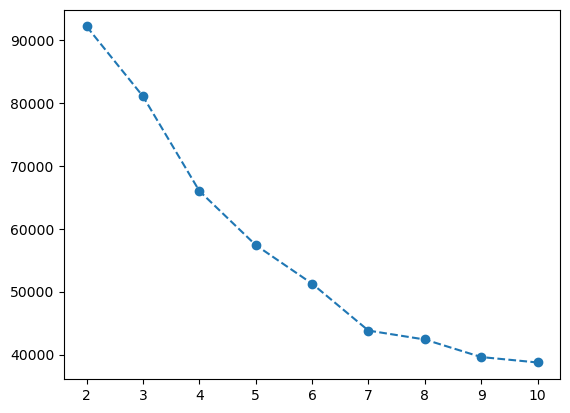

In [17]:
# Let's plot this
plt.plot(range(2, 11), ssd, 'o--')

- Let's find the difference between the SSDs

In [18]:
pd.Series(ssd).diff()

0             NaN
1   -11106.253744
2   -15037.119433
3    -8590.094025
4    -6135.872644
5    -7453.884756
6    -1414.371344
7    -2789.185765
8     -862.167761
dtype: float64

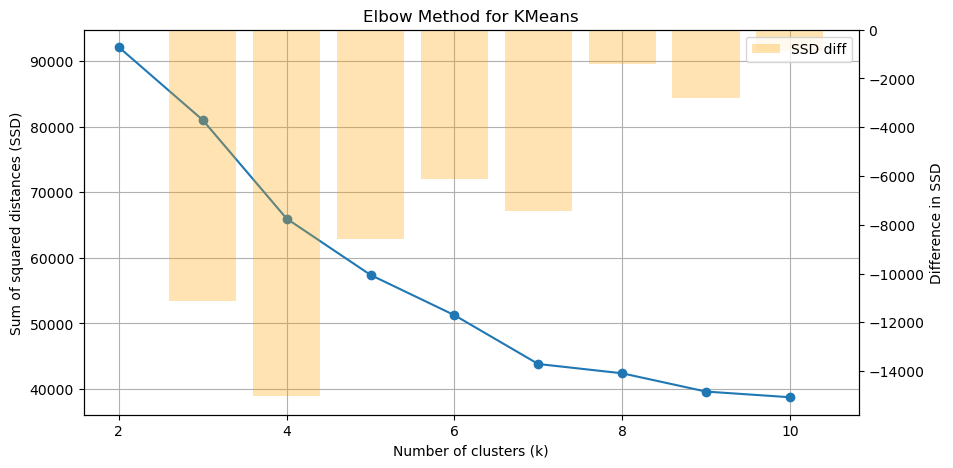

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Your SSD values for k=2 to 10
K_range = range(2, 11)
# replace with your real SSD values

# Convert to Series for diff calculation
ssd_series = pd.Series(ssd, index=K_range)
ssd_diff = ssd_series.diff()

# Plot SSD vs K
plt.figure(figsize=(10,5))
plt.plot(K_range, ssd, 'o-', label='SSD (Inertia)')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (SSD)')
plt.grid(True)

# Optional: show the difference as a bar
plt.twinx()
plt.bar(K_range, ssd_diff, alpha=0.3, color='orange', label='SSD diff')
plt.ylabel('Difference in SSD')
plt.legend(loc='upper right')

plt.show()


---
### KMeans Clustering Interpretation

We applied KMeans clustering to our scaled satellite dataset and used the **Elbow Method** to determine the optimal number of clusters.  

**Elbow Analysis:**  
- The plot of **Sum of Squared Distances (SSD) vs. number of clusters (k)** shows that SSD decreases sharply at first, then the rate of decrease slows down.  
- The **difference in SSD** (`.diff()`) highlights how much each additional cluster improves clustering.  
- Observing the plot, the “elbow” appears around **k = 5**, where adding more clusters provides diminishing returns.  

**Cluster Summary (k = 5):**  
1. **Cluster 0:**  
   - Low inclination (orbits close to equator)  
   - ARG_OF_PERICENTER above average → closest approach happens later along orbit  
   - Relatively new satellites  

2. **Cluster 1:**  
   - Moderate-to-high inclination → satellites tilted more from equator  
   - Average orbital orientation and age  

3. **Cluster 2:**  
   - Features close to dataset average → “typical” satellites  
   - No extreme orbital characteristics  

4. **Cluster 3:**  
   - High age and number of revolutions → older satellites  
   - Moderate inclination and ARG_OF_PERICENTER  

5. **Cluster 4:**  
   - Oldest satellites with many revolutions  
   - High inclination → likely polar or near-polar orbits  
   - Moderate ARG_OF_PERICENTER  




-----
#### Validating more for optimal K value
- We will use n_init=50 and also validate using the  Silhouette Score

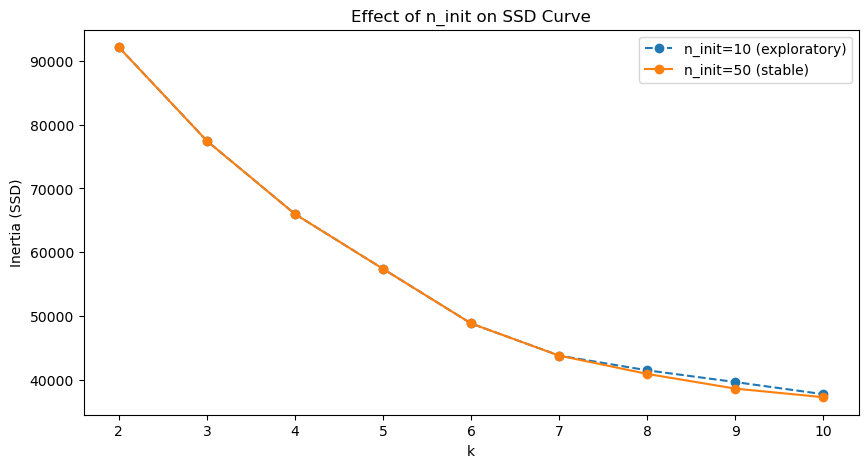

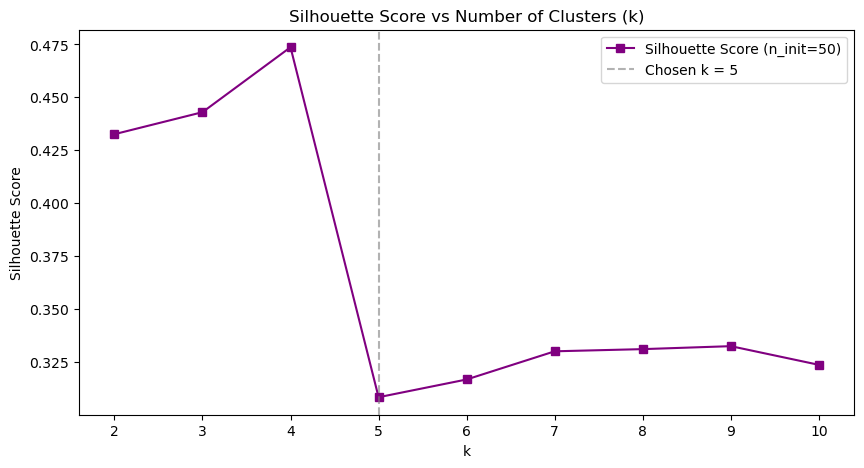

,k,SSD (n_init=50),Silhouette Score
0,2,92136.139049,0.432610
1,3,77452.409724,0.443007
2,4,65992.765872,0.473679
3,5,57402.671847,0.308434
4,6,48848.934508,0.316815
5,7,43812.914446,0.330114
6,8,40945.424571,0.331141
7,9,38642.982071,0.332541
8,10,37294.765844,0.323719


In [20]:
#!-------------- NOTE:  This code takes ages to run !! ------------------
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

ssd_10, ssd_50, sil_scores = [], [], []

for k in range(2, 11):
    km10 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    km50 = KMeans(n_clusters=k, n_init=50, random_state=42).fit(X)
    
    ssd_10.append(km10.inertia_)
    ssd_50.append(km50.inertia_)
    
    # silhouette score (using the more stable fit)
    labels = km50.labels_
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

# --- Plot 1: SSD (Inertia) ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), ssd_10, 'o--', label='n_init=10 (exploratory)')
plt.plot(range(2, 11), ssd_50, 'o-', label='n_init=50 (stable)')
plt.legend()
plt.title("Effect of n_init on SSD Curve")
plt.xlabel("k")
plt.ylabel("Inertia (SSD)")
plt.show()

# --- Plot 2: Silhouette Scores ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='purple', label='Silhouette Score (n_init=50)')
plt.axvline(5, color='gray', linestyle='--', alpha=0.6, label='Chosen k = 5')
plt.legend()
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# --- Optional: print table ---
pd.DataFrame({
    'k': range(2, 11),
    'SSD (n_init=50)': ssd_50,
    'Silhouette Score': sil_scores
})


--- 
### 🛰️ Cluster Selection Analysis (KMeans)

We used two standard methods to determine the optimal number of clusters for our satellite dataset — the **Elbow Method** and the **Silhouette Score**.

#### 1. Elbow Method
The Elbow Method evaluates how the total **within-cluster variance (SSD)** decreases as the number of clusters (K) increases.  
In our case, the curve showed a clear “bend” or **elbow around K = 5**, indicating that after 5 clusters, the improvement in compactness slows down.  
This suggests that **five clusters offer a balanced tradeoff** between capturing meaningful structure and avoiding overfitting.

#### 2. Silhouette Score
The Silhouette Score measures **how well each data point fits within its cluster compared to others**, ranging from -1 to +1.  
A higher score means better separation between clusters.  
Our scores peaked at **K = 2 (≈0.55)**, suggesting that the dataset could be broadly separated into two main groups.  
However, since our dataset includes **only LEO-type satellites (no GEO or MEO)**, this “two-cluster” pattern likely reflects very broad distinctions (e.g., stable vs. decaying orbits), rather than detailed substructures.

#### 3. Why They Differ
- **Elbow** focuses on minimizing internal variance (compactness).
- **Silhouette** focuses on maximizing separation (distinctness).
- When both methods disagree, it usually means the data has **one dominant split** but also **smaller, meaningful variations** within that main structure.

#### 4. Final Choice — K = 5
We selected **K = 5** because:
- It aligns with the elbow point, balancing compactness and complexity.  
- It allows for finer segmentation of orbital behavior — capturing subtle subgroups such as:
  - satellites with stable vs. decaying orbits,  
  - newer vs. older launches,  
  - variations in inclination or mean motion behavior.  

Thus, **K = 5** provides a richer, more interpretable analysis of LEO satellite dynamics without oversimplifying the orbital diversity present in the dataset.


---
### Save the model output as CSV file
- Save both scaled+label  and unscaled+label 

In [21]:
# Save scaled version with the orignal scaled cols + cluster labels
df['CLUSTER'] = X['CLUSTER']

df.to_csv('../data/05_labeled/satellites_scaled_labeled.csv', index=False)

In [22]:
# Save the unscaled version (for anomaly detection)
import joblib

# Import the featured engineered dataset (containing unscaled data values)
unscaled = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

# Get the encoder which we used to encode the engineered dataset
encoder = joblib.load('../data/04_scaled/encoder_sat_type.joblib')

# Apply the same encoding
encoded = encoder.transform(unscaled[['SAT_TYPE']])

df_encoded = pd.concat([unscaled.drop('SAT_TYPE', axis=1), pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['SAT_TYPE']))], axis=1)

# Merge the corresponding cluster label
df_encoded['CLUSTER'] = X['CLUSTER']

# Remove unnecessary columns
df_encoded = df_encoded.drop(['OBJECT_NAME', 'EPOCH', 'NORAD_CAT_ID'], axis=1)

# Save the CSV
df_encoded.to_csv('../data/05_labeled/satellites_unscaled_labeled.csv', index=False)

In [23]:
df_encoded

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,4466,0.001228,1.211000e-05,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,82995,0.000097,7.400000e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,93412,0.000160,8.900000e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,93673,0.000319,1.750000e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,3753,0.003397,2.236400e-04,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12742,14.930341,0.001368,97.7386,265.9163,312.7426,47.2642,118,0.000525,5.415000e-05,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
12743,14.930896,0.001410,97.7387,265.7189,312.6803,47.3228,115,0.000388,3.993000e-05,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
12744,15.493060,0.000360,51.6299,183.0583,202.7086,157.3744,117,0.000293,1.591000e-04,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
12745,14.983106,0.000975,97.6394,281.9587,255.3935,104.6207,2,0.000084,9.470000e-06,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


- Quick sanity check, wether or not the labels are correct or not

In [24]:
df_encoded['CLUSTER'].value_counts().sort_values()

CLUSTER
3     184
2    1458
4    2106
0    4389
1    4610
Name: count, dtype: int64

In [25]:
len(df_encoded)

12747

----
#### Interpreting the model result

In [26]:
# Cluster profiles

cluster_profiles = df_encoded.groupby('CLUSTER')[['MEAN_MOTION', 'ORBIT_HEIGHT'  ,'INCLINATION', 'ECCENTRICITY', 'BSTAR', 'AGE_SINCE_LAUNCH']].mean()
print(cluster_profiles)

         MEAN_MOTION  ORBIT_HEIGHT  INCLINATION  ECCENTRICITY     BSTAR  \
CLUSTER                                                                   
0          15.206327    511.951588    50.586222      0.000215  0.000730   
1          15.211247    510.484240    50.037102      0.000243  0.000994   
2          13.586035   1058.639258    85.432865      0.002243  0.000388   
3          15.546706    410.882223    46.081524      0.000258 -0.034608   
4          15.141108    532.499574    97.175545      0.000678  0.000906   

         AGE_SINCE_LAUNCH  
CLUSTER                    
0                2.637852  
1                2.576308  
2                7.768556  
3                0.930435  
4                2.935313  


C:\Users\sushr\AppData\Local\Temp\ipykernel_179920\2051917219.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x = 'CLUSTER', y = 'AGE_SINCE_LAUNCH', ax = axes[2], palette = 'Set1')
C:\Users\sushr\AppData\Local\Temp\ipykernel_179920\2051917219.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(bbox_to_anchor=(1, 1), loc='upper left')


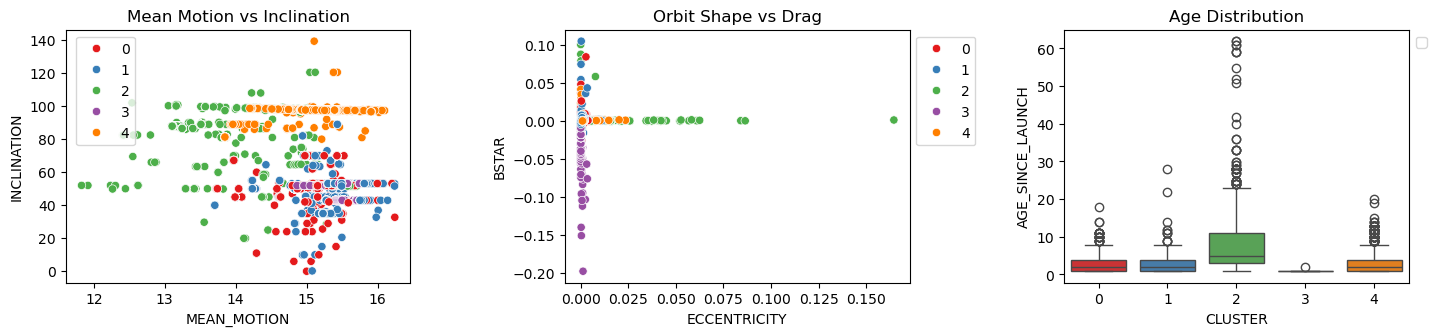

In [27]:
# Quick visualization for between the features across the clusters

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# mean motion vs inclination
sns.scatterplot(data=df_encoded, x = 'MEAN_MOTION', y = 'INCLINATION', hue = 'CLUSTER', ax = axes[0], palette = 'Set1')
axes[0].legend(bbox_to_anchor=(0.01, 1), loc='upper left')
axes[0].set_title('Mean Motion vs Inclination')

# Orbit shape vs drag
sns.scatterplot(data=df_encoded, x = 'ECCENTRICITY', y = 'BSTAR', hue = 'CLUSTER', ax = axes[1], palette = 'Set1')
axes[1].legend(bbox_to_anchor=(1, 1), loc='upper left')
axes[1].set_title('Orbit Shape vs Drag')

# Age distribution
sns.boxplot(data=df_encoded, x = 'CLUSTER', y = 'AGE_SINCE_LAUNCH', ax = axes[2], palette = 'Set1')
axes[2].legend(bbox_to_anchor=(1, 1), loc='upper left')
axes[2].set_title('Age Distribution')
plt.tight_layout(pad=3)
